# SCO Manuscript – Figure Generation

## Setup

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler
import seaborn as sns
from scipy.io import loadmat
from pandas import read_table, read_csv
from scipy.signal import find_peaks

# Global theme
sns.set_theme(context='paper', style='white')
mpl.rcParams['svg.fonttype'] = 'none'
FAM, SMALL, MEDIUM, LARGE = 'Verdana', 10, 14, 16

plt.rc('font', size=SMALL, family=FAM)
plt.rc('axes', titlesize=MEDIUM, labelsize=SMALL)
plt.rc('xtick', labelsize=SMALL)
plt.rc('ytick', labelsize=SMALL)
plt.rc('legend', fontsize=SMALL)
plt.rc('figure', titlesize=LARGE)

# Style a 3D surface axis
def style_3d(ax):
    ax.grid(False)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor('white')
        axis.pane.set_linewidth(1)
    ax.view_init(elev=30, azim=-60)
    ax.set_box_aspect(None, zoom=0.80)

# Remove top/right spines
def clean_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## Data Loading

In [135]:
# Simulated phase time-series, standardise to 100s at dt = 0.01
theta_human = loadmat('./dependencies/theta_human')['Theta_Down'].T[:, :10000]
theta_macaque = loadmat('./dependencies/theta_macaque')['Theta'].T[:, ::10]

# Parameter sweeps
sweep_hetero_human = loadmat('./figure_data/sweep_hetero_human.mat')
sweep_homo_human = loadmat('./figure_data/sweep_homo_human.mat')
sweep_hetero_macaque = loadmat('./figure_data/sweep_hetero_macaque.mat')
sweep_homo_macaque = loadmat('./figure_data/sweep_homo_macaque.mat')
sweep_hetero_aal = loadmat('./figure_data/sweep_hetero_aal.mat')
sweep_homo_aal = loadmat('./figure_data/sweep_homo_aal.mat')

# Human network parcellation (Schaefer 1000)
labels_n = [name[11:] for name in read_csv('./dependencies/LUT_schaefer.csv')['ROI Name']]
networks_human = {
    name: [i for i, lbl in enumerate(labels_n) if name in lbl]
    for name in ('TempPar', 'Default')
}
networks_human['all'] = np.arange(1000, dtype=int)

# Macaque network parcellation (RM82)
lut_macaque = read_table('./dependencies/LUT_shen.txt')
tp_regions = ['secondary auditory cortex', 'inferior parietal cortex',
                'superior temporal cortex', 'central temporal cortex']
dmn_regions = ['medial prefrontal cortex', 'medial parietal cortex',
                'retrosplenial cingulate cortex', 'posterior cingulate cortex',
                'dorsolateral prefrontal cortex']
networks_macaque = {
    'all':     np.arange(82, dtype=int),
    'TempPar': np.where(lut_macaque['name'].isin(tp_regions))[0],
    'Default': np.where(lut_macaque['name'].isin(dmn_regions))[0],
}

# Cortical coordinates
coords_n = loadmat('./dependencies/schaefercog.mat')['SchaeferCOG']

---
## Figure 2 – Emergence of periodic integration in the human and macaque connectomes

### Figure 2b – Coherence time-series for the whole cortex, temporo-parietal and default mode networks

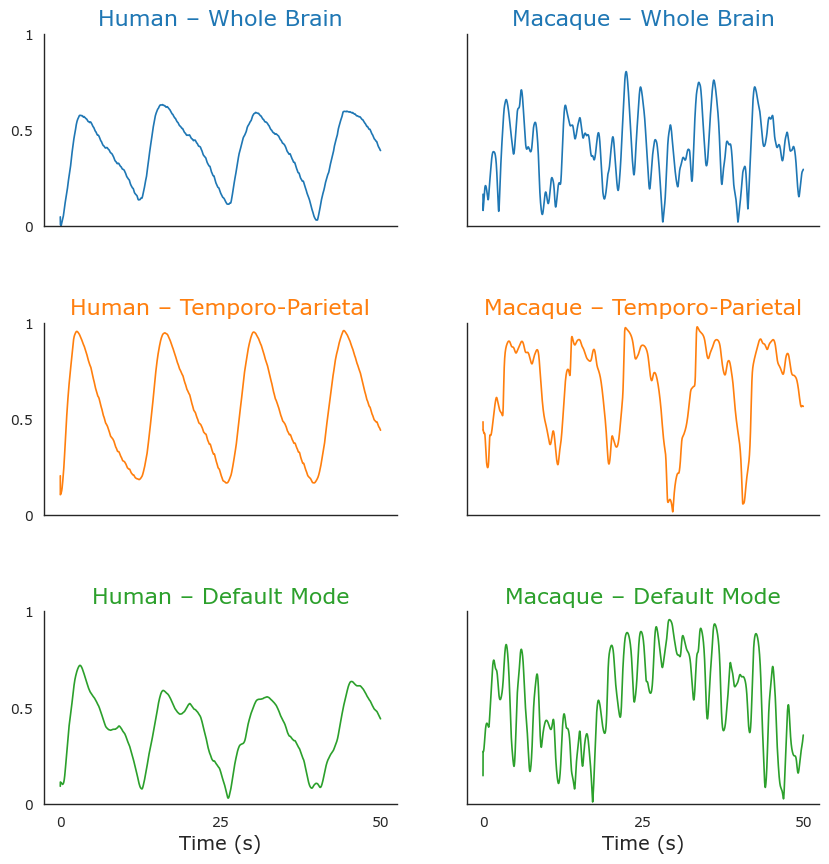

In [136]:
fig, axs = plt.subplots(3, 2, sharex=True, sharey=True, figsize=(10, 10))
fig.subplots_adjust(hspace=0.5)

cmap_ts = plt.cm.tab10(np.linspace(0, 1, 8))
x = np.linspace(0, 50, 5000)
titles = ['Whole Brain', 'Temporo-Parietal', 'Default Mode']
keys = ['all', 'TempPar', 'Default']

for col, (theta, networks) in enumerate([(theta_human, networks_human),(theta_macaque, networks_macaque)]):
    for row, key in enumerate(keys):
        ax = axs[row, col]
        clean_spines(ax)
        ax.set_ylim(0, 1)
        ax.set_yticks(np.linspace(0, 1, 3), labels=[0, 0.5, 1])
        r = np.abs(np.mean(np.exp(1j * theta[networks[key], :5000]), axis=0))
        ax.plot(x, r, c=cmap_ts[row])
        species = 'Human' if col == 0 else 'Macaque'
        ax.set_title(f'{species} – {titles[row]}', c=cmap_ts[row], size=16)

for col in range(2):
    axs[2, col].set_xticks(np.linspace(0, 50, 3), labels=[0, 25, 50])
    axs[2, col].set_xlabel('Time (s)', size=14)

plt.show()

### Figure 2b (phase plots) – Regional phase scatter at coherence peak and trough

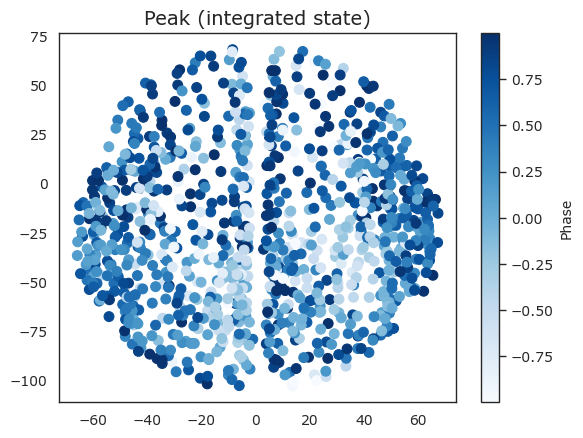

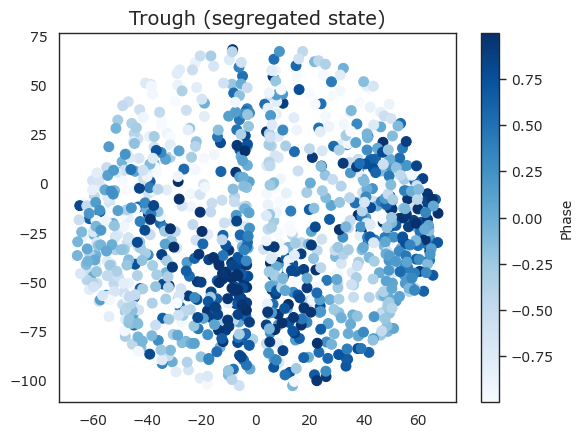

In [137]:
coh_ds = np.abs(np.mean(np.exp(1j * theta_human), axis=0))
peaks = find_peaks( coh_ds, prominence=0.4)[0]
troughs = find_peaks(-coh_ds, prominence=0.4)[0]

xs, ys = coords_n[:, 0], coords_n[:, 1]

for label, t_idx in [('Peak (integrated state)', peaks[1]), ('Trough (segregated state)', troughs[1])]:
    fig, ax = plt.subplots()
    sc = ax.scatter(xs, ys, s=200, c=np.sin(theta_human[:, t_idx]), cmap='Blues', marker='.')
    ax.set_title(label)
    plt.colorbar(sc, ax=ax, label='Phase')
    plt.show()

### Figure 2c – Standard deviation of cortical coherence (metastability) over the parameter space

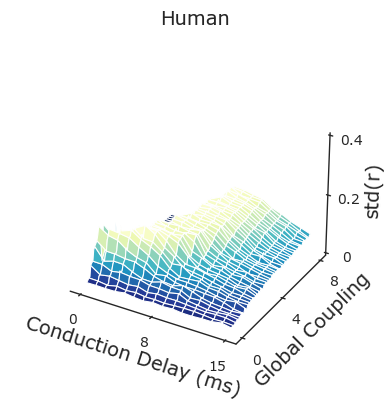

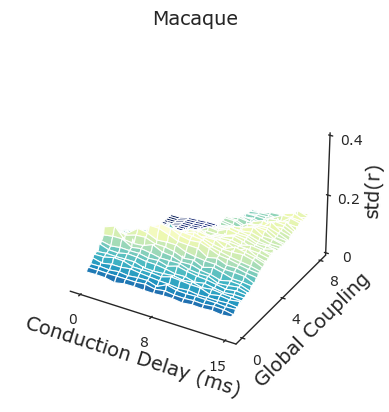

In [138]:
g = sweep_hetero_human['G'].squeeze()
delay = sweep_hetero_human['delay'].squeeze()
D, G = np.meshgrid(delay, g)

panels = [
    (sweep_hetero_human['mtsb'], 'Human'),
    (sweep_hetero_macaque['mtsb'], 'Macaque'),
]

for mtsb, title in panels:
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(D, G, mtsb, antialiased=True, cmap='YlGnBu_r')
    style_3d(ax)
    ax.set_xticks(np.linspace(0, 15, 3), labels=[0, 8, 15])
    ax.set_xlabel('Conduction Delay (ms)', size=14)
    ax.set_yticks(np.linspace(0, 8, 3), labels=[0, 4, 8])
    ax.set_ylabel('Global Coupling', size=14)
    ax.set_zticks(np.linspace(0, 0.4, 3), labels=[0, 0.2, 0.4])
    ax.set_zlabel('std(r)', size=14)
    ax.set_title(title)
    plt.show()

### Figure 2d – Coherence oscillation frequency over the parameter space (heterogeneous ω, 8–12 Hz)

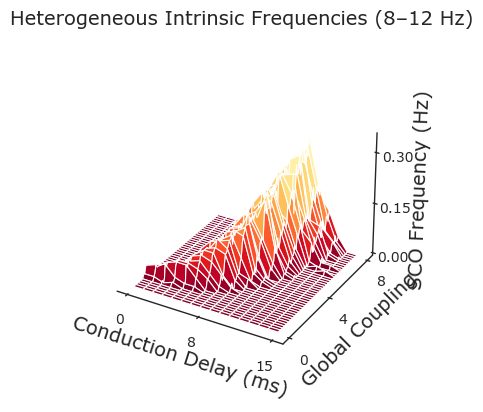

In [139]:
g = sweep_hetero_human['G'].squeeze()
delay = sweep_hetero_human['delay'].squeeze()
D, G = np.meshgrid(delay, g)

sweeps = {
    'hetero': (sweep_hetero_human, sweep_hetero_human['ord_param'][:, :, 17, :]),
    'homo':   (sweep_homo_human, sweep_homo_human['ord_param']),
}

freqs = {}
for name, (sweep, op) in sweeps.items():
    mtsb = sweep['mtsb']
    f = np.zeros_like(mtsb)
    for i in range(mtsb.shape[0]):
        for j in range(mtsb.shape[1]):
            f[i, j] = len(find_peaks(op[i, j, :], prominence=0.4)[0]) / 100
    freqs[name] = f

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(D, G, freqs['hetero'], antialiased=True, cmap='YlOrRd_r')
style_3d(ax)
ax.set_xticks(np.linspace(0, 15, 3), labels=[0, 8, 15])
ax.set_xlabel('Conduction Delay (ms)', size=14)
ax.set_yticks(np.linspace(0, 8, 3), labels=[0, 4, 8])
ax.set_ylabel('Global Coupling', size=14)
ax.set_zticks(np.linspace(0, 0.3, 3))
ax.set_zlabel('SCO Frequency (Hz)', size=14)
ax.set_title('Heterogeneous Intrinsic Frequencies (8–12 Hz)')
plt.show()

### Figure 2e – Effect of intrinsic frequency heterogeneity (homogeneous ω, 12 Hz)

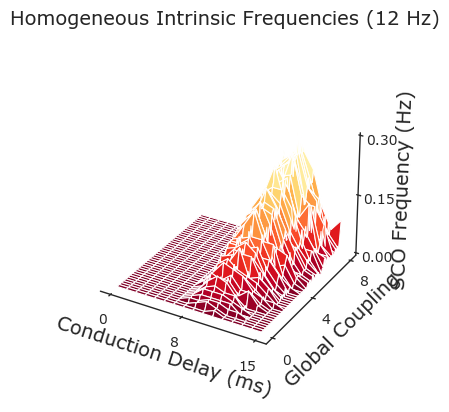

In [140]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(D, G, freqs['homo'], antialiased=True, cmap='YlOrRd_r')
style_3d(ax)
ax.set_xticks(np.linspace(0, 15, 3), labels=[0, 8, 15])
ax.set_xlabel('Conduction Delay (ms)', size=14)
ax.set_yticks(np.linspace(0, 8, 3), labels=[0, 4, 8])
ax.set_ylabel('Global Coupling', size=14)
ax.set_zticks(np.linspace(0, 0.3, 3))
ax.set_zlabel('SCO Frequency (Hz)', size=14)
ax.set_title('Homogeneous Intrinsic Frequencies (12 Hz)')
plt.show()

---
## Figure 3 – Order parameter for null models

### Figure 3a – Order parameter time-series: randomized structural connectivity (human and macaque)

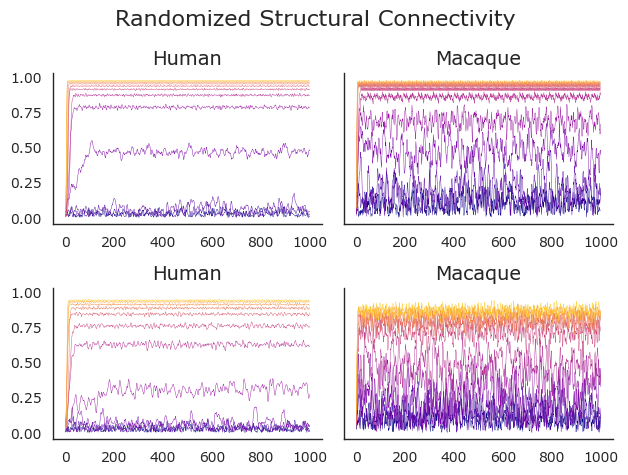

In [148]:
randconn_human = loadmat('./figure_data/randconn_results_human')
randconn_macaque = loadmat('./figure_data/randconn_results_macaque')
lorentz_res = loadmat('./figure_data/lorentz_results')

op_rand_human = randconn_human['ord_param']
op_rand_macaque = randconn_macaque['ord_param']
op_lorentz = lorentz_res['ord_param']

fig, axs = plt.subplots(2, 2, sharey=True)
cmap_rc = plt.cm.plasma(np.linspace(0, 8, 100))
delay_idx = [1, 10]

for i, ax in enumerate(axs.flat):
    clean_spines(ax)
    ax.set_yticks(np.linspace(0, 1, 5))
    ax.set_prop_cycle(cycler('color', cmap_rc))
    op = op_rand_human if i % 2 == 0 else op_rand_macaque
    ax.plot(op[1:81:7, delay_idx[i // 2], :].T, linewidth=0.3)
    ax.set_title('Human' if i % 2 == 0 else 'Macaque')

plt.suptitle('Randomized Structural Connectivity')
plt.tight_layout()
plt.show()

### Figure 3b – Order parameter time-series: all-to-all connectivity with Lorentzian frequency distribution

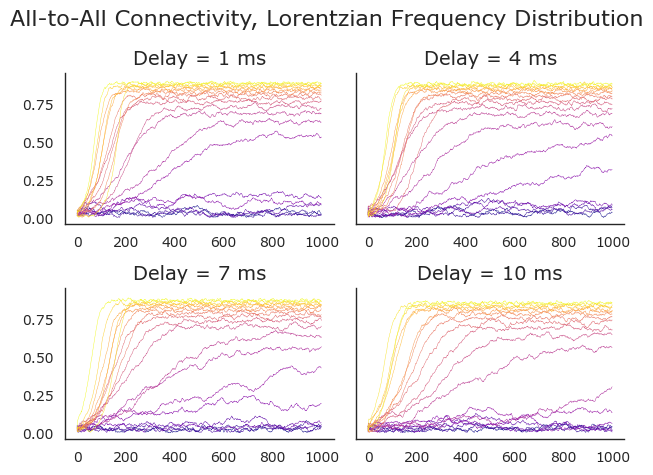

In [149]:
fig, axs = plt.subplots(2, 2, sharey=True)
cmap_lor = plt.cm.plasma(np.linspace(0, 1, 20))
delay_idx = [1, 4, 7, 10]

for i, ax in enumerate(axs.flat):
    clean_spines(ax)
    ax.set_yticks(np.linspace(0, 1, 5))
    ax.set_prop_cycle(cycler('color', cmap_lor))
    ax.plot(op_lorentz[1:81, delay_idx[i], :].T, linewidth=0.3)
    ax.set_title(f'Delay = {delay_idx[i]} ms')

plt.suptitle('All-to-All Connectivity, Lorentzian Frequency Distribution')
plt.tight_layout()
plt.show()

### Figure 3c–f – Metastability over the parameter space (human, randomized human, randomized macaque, Lorentzian)

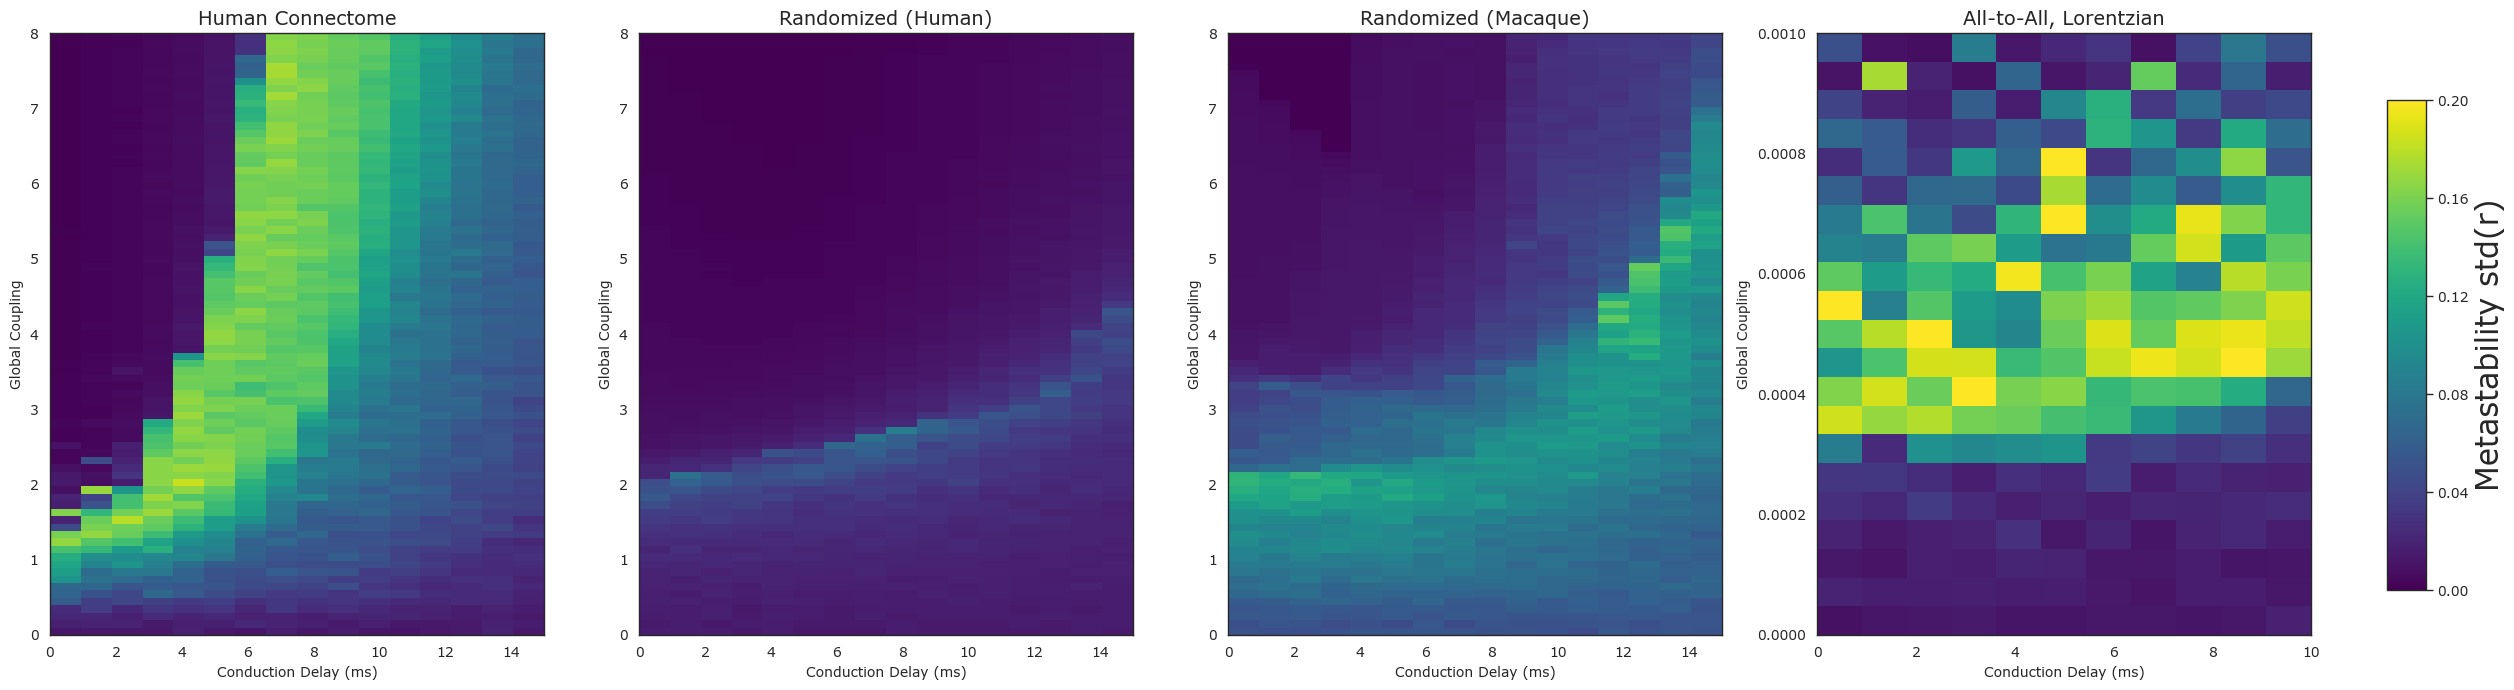

In [150]:
mtsb_panels = [
    (sweep_hetero_human['mtsb'], sweep_hetero_human, 'Human Connectome'),
    (randconn_human['mtsb'], sweep_hetero_human, 'Randomized (Human)'),
    (randconn_macaque['mtsb'], sweep_hetero_human, 'Randomized (Macaque)'),
    (lorentz_res['mtsb'], lorentz_res, 'All-to-All, Lorentzian'),
]

VMIN, VMAX = 0.00, 0.20
fig, axes = plt.subplots(1, 4, figsize=(26, 7))

for ax, (mtsb, ref, title) in zip(axes, mtsb_panels):
    d = ref['delay']
    G = ref['G']
    im = ax.imshow(
        mtsb,
        extent=[d.min(), d.max(), G.min(), G.max()],
        origin='lower', aspect='auto', cmap='viridis',
        vmin=VMIN, vmax=VMAX,
    )
    ax.set_title(title)
    ax.set_xlabel('Conduction Delay (ms)')
    ax.set_ylabel('Global Coupling')

fig.tight_layout(rect=[0, 0, 0.90, 1])
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
ticks = np.linspace(VMIN, VMAX, 6)
cbar = fig.colorbar(im, cax=cbar_ax, ticks=ticks)
cbar.ax.set_yticklabels([f'{t:.2f}' for t in ticks])
cbar.set_label('Metastability std(r)', fontsize=22)

plt.show()

---
## Figure 4 – Frustrated synchronization and periodic order parameter

### Figure 4f – Order parameter at each level of a hierarcho-modular network

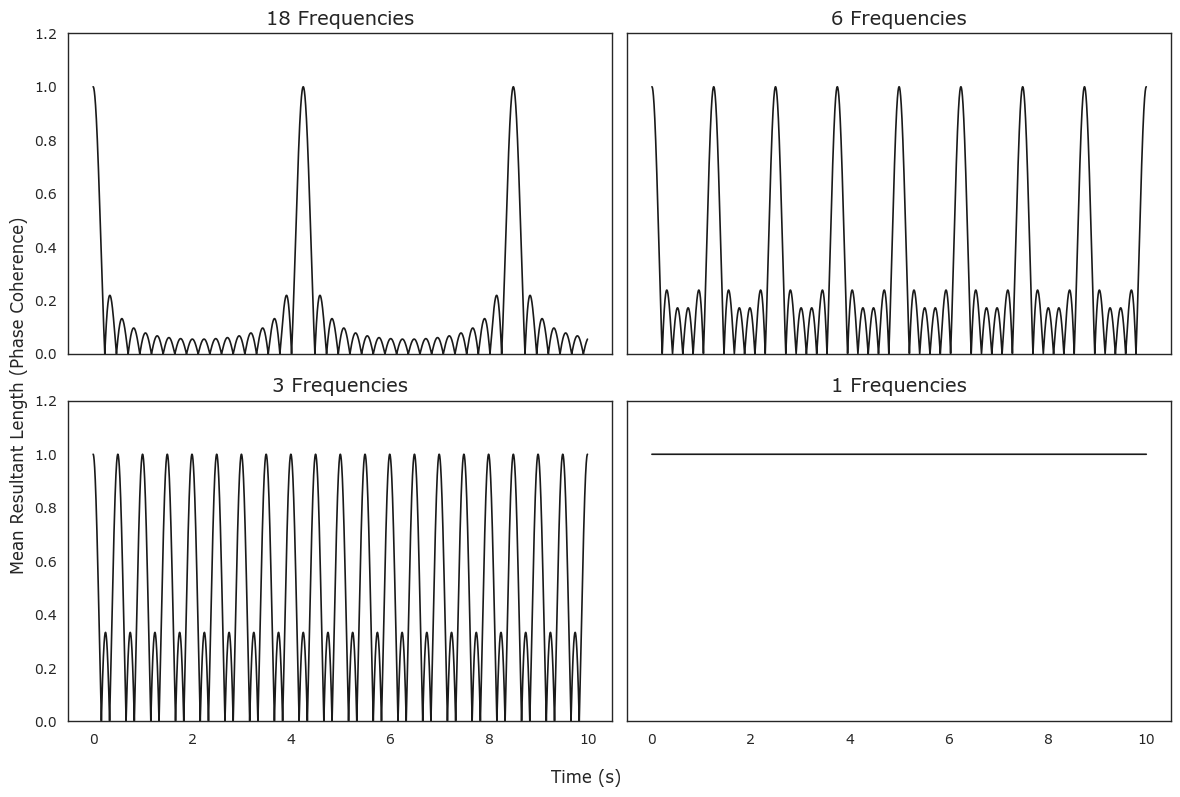

In [159]:
hfreq_res = loadmat('./figure_data/toy_hfreq_results.mat')
hcoupling_res = loadmat('./figure_data/toy_hcoupling_results.mat')

t = np.arange(0, 10.001, 0.001)
freq_counts = [18, 6, 3, 1]  # levels L3 → L0
LOW_F, HIGH_F = 8, 12

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for ax, n_freqs in zip(axes.flat, freq_counts):
    frqs = np.linspace(LOW_F, HIGH_F, n_freqs)
    phase = 2 * np.pi * frqs[:, np.newaxis] * t
    r = np.abs(np.mean(np.exp(1j * phase), axis=0))
    ax.plot(t, r, 'k')
    ax.set_title(f'{n_freqs} Frequencies')
    ax.set_ylim([0, 1.2])

fig.supxlabel('Time (s)')
fig.supylabel('Mean Resultant Length (Phase Coherence)')
plt.tight_layout()
plt.show()

### Figure 4g – Order parameter frequency as a function of frequency dispersion or coupling

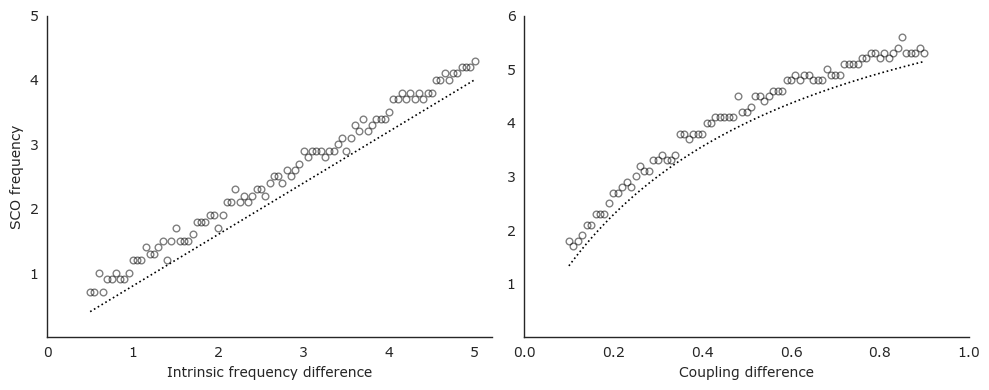

In [160]:
# Frequency-difference sweep
r1 = hfreq_res['r']
f_A = hfreq_res['f_A']
f_B = hfreq_res['f_B']
f_diff = hfreq_res['f_diff']

K, N, DT = 0.1, 500, 0.005
denom = 1 + N * K * DT

frq1 = np.array([len(find_peaks(r1[ii, :])[0]) for ii in range(91)])
w1 = (f_A / denom) - (f_B / denom)

# Coupling-difference sweep
r2 = hcoupling_res['r']
k_A = hcoupling_res['k_A']
k_diff = hcoupling_res['k_diff']

frq2 = np.array([len(find_peaks(r2[ii, :])[0]) for ii in range(81)])
w2 = (10 / (1 + N * k_A * DT)) - (10 / denom)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
scatter_kw = dict(marker='o', linestyle='none', markeredgecolor='black', markerfacecolor='none', alpha=0.5)

axs[0].plot(f_diff[0, :], frq1 / 10, **scatter_kw)
axs[0].plot(f_diff[0, :], np.abs(np.squeeze(w1)), color='black', linestyle=':')
axs[0].set_xlabel('Intrinsic frequency difference')
axs[0].set_ylabel('SCO frequency')
axs[0].set_ylim(0,5)
axs[0].set_xlim(0,5.2)
axs[0].set_yticks(np.linspace(1,5,5))

axs[1].plot(k_diff[0, :], frq2 / 10, **scatter_kw)
axs[1].plot(k_diff[0, :], np.abs(np.squeeze(w2)), color='black', linestyle=':')
axs[1].set_xlabel('Coupling difference')
axs[1].set_ylim(0,6)
axs[1].set_xlim(0,1)
axs[1].set_yticks(np.linspace(1,6,6))

for ax in axs:
    clean_spines(ax)
    ax.tick_params(direction='out', length=3, width=1)

plt.tight_layout()
plt.show()

---
## Figure 5 – Competitive entrainment in the cortical model

### Figure 5c – Time-frequency decomposition of the simulated sensory node

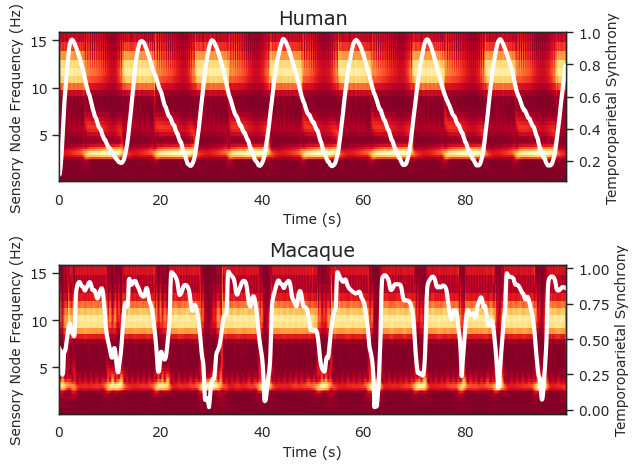

In [144]:
results_human = loadmat('./figure_data/entrainment_results_human.mat')
results_macaque = loadmat('./figure_data/entrainment_results_macaque.mat')

tp_coh_human = np.abs(np.mean(np.exp(1j * theta_human[networks_human['TempPar'], :]), axis=0))
tp_coh_macaque = np.abs(np.mean(np.exp(1j * theta_macaque[networks_macaque['TempPar'],:]), axis=0))

panels = [
    (results_human['f'][15:100], results_human['wt'][15:100, 20000:30000],
     tp_coh_human[::10], 'Human'),
    (results_macaque['f'][15:100], results_macaque['wt'][15:100, 1:],
     tp_coh_macaque[1::10], 'Macaque'),
]

fig, axs = plt.subplots(2, 1)

for ax, (f, wt, coh, title) in zip(axs, panels):
    ax.pcolormesh(np.arange(0, 100, 0.01), f, np.abs(wt), cmap='YlOrRd_r')
    twin = ax.twinx()
    twin.plot(np.arange(0, 100, 0.1), coh, linewidth=3, color='white')
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Sensory Node Frequency (Hz)')
    twin.set_ylabel('Temporoparietal Synchrony')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)

plt.tight_layout()
plt.show()

---
## Figure 6 – Cholinergic modulation

### Figure 6b, 6d – TPN coherence oscillation frequency under multiplicative gain (human, left and right)

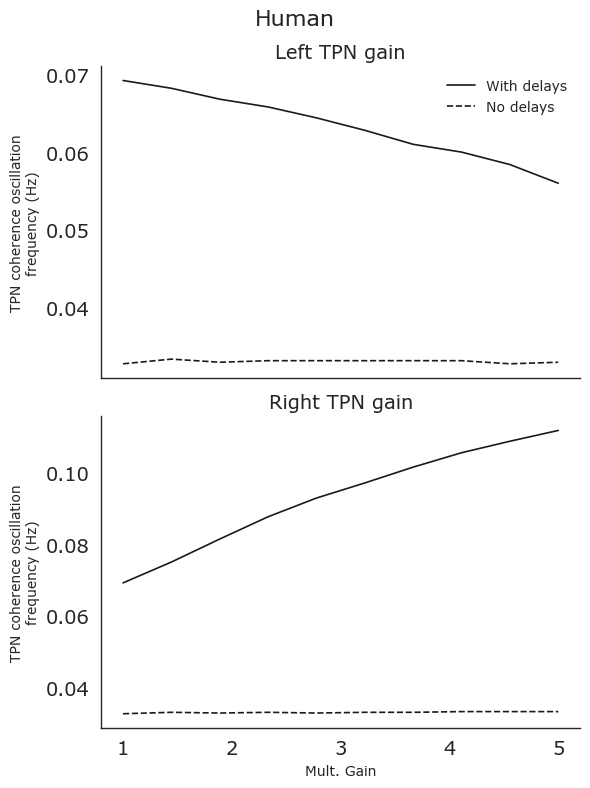

In [ ]:
gain_results = {
    'human':   [loadmat('./figure_data/gainmod_results_human_left.mat'),
                loadmat('./figure_data/gainmod_results_human_right.mat')],
    'macaque': [loadmat('./figure_data/gainmod_results_macaque_left.mat'),
                loadmat('./figure_data/gainmod_results_macaque_right.mat')],
}

gains = np.linspace(1, 5, 10)
side_labels = ['Left TPN gain', 'Right TPN gain']

fig, axs = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
fig.suptitle('Human')

for ax, results, side in zip(axs, gain_results['human'], side_labels):
    clean_spines(ax)
    ax.plot(gains, results['mean_gain_peaks'][0], color='k', linestyle='-', label='With delays')
    ax.plot(gains, results['mean_gain_peaks_nd'][0], color='k', linestyle='--', label='No delays')
    ax.set_ylabel('TPN coherence oscillation\nfrequency (Hz)')
    ax.set_title(side)
    ax.tick_params(labelsize=14)

axs[-1].set_xlabel('Mult. Gain')
axs[0].legend(frameon=False)
plt.tight_layout()
plt.show()

### Figure 6e, 6g – TPN coherence oscillation frequency under multiplicative gain (macaque, left and right)

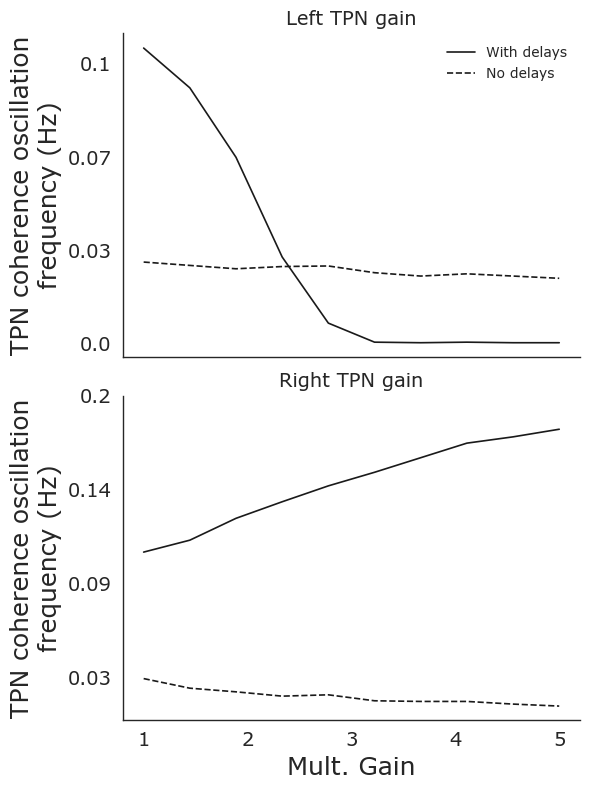

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

for ax, results, side in zip(axs, gain_results['macaque'], side_labels):
    clean_spines(ax)
    ax.plot(gains, results['mean_gain_peaks'][0], color='k', linestyle='-', label='With delays')
    ax.plot(gains, results['mean_gain_peaks_nd'][0], color='k', linestyle='--', label='No delays')
    ax.set_ylabel('TPN coherence oscillation\nfrequency (Hz)', fontsize=18)
    ax.set_title(side)
    ax.set_xticks(np.linspace(1,5,5).round(2)) 
    ax.tick_params(labelsize=14)

axs[-1].set_xlabel('Mult. Gain', fontsize=18)
axs[0].set_yticks(np.linspace(0,0.1,4), labels=np.linspace(0,0.1,4).round(2))
axs[1].set_yticks(np.linspace(0.03,0.2,4), labels=np.linspace(0.03,0.2,4).round(2))

axs[0].legend(frameon=False)
plt.tight_layout()
plt.show()

### Supplementary Figure 1 – Frequency Heterogeneity and SCO frequency for Macaque and AAL connectomes

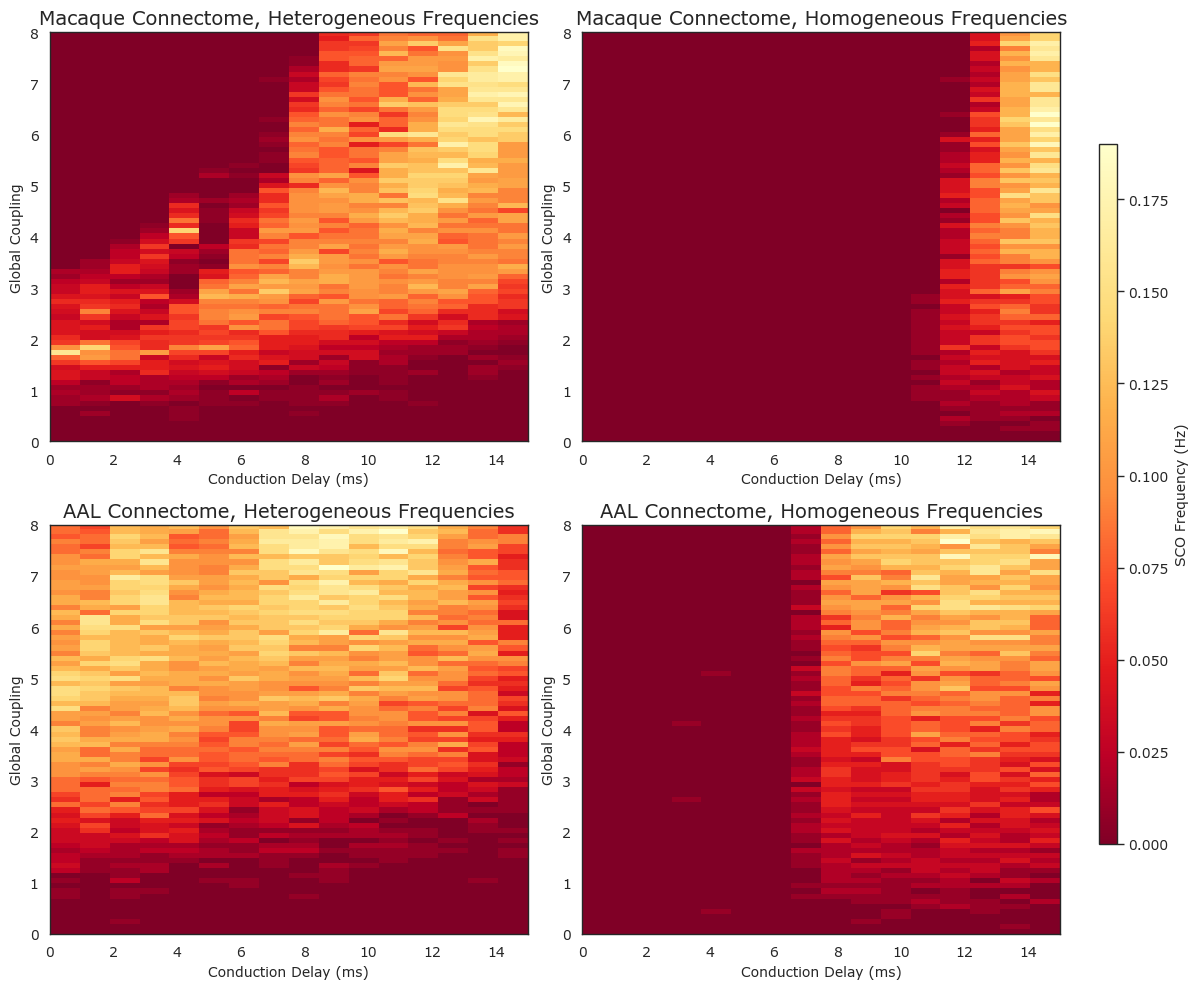

In [151]:
g = sweep_hetero_macaque['G'].squeeze()
delay = sweep_hetero_macaque['delay'].squeeze()
D, G = np.meshgrid(delay, g)

sweeps = {
    'hetero_m': (sweep_hetero_macaque, sweep_hetero_macaque['ord_param'][:, :, 2, :]),
    'homo_m':   (sweep_homo_macaque, sweep_homo_macaque['ord_param'][:, :, 2, :]),
    'hetero_aal': (sweep_hetero_aal, sweep_hetero_aal['ord_param'][:, :, 2, :]),
    'homo_aal': (sweep_homo_aal, sweep_homo_aal['ord_param'][:, :, 2, :]) 
}

freqs = {}
for name, (sweep, op) in sweeps.items():
    mtsb = sweep['mtsb']
    f = np.zeros_like(mtsb)
    for i in range(mtsb.shape[0]):
        for j in range(mtsb.shape[1]):
            f[i, j] = len(find_peaks(op[i, j, :], prominence=0.4)[0]) / 100
    freqs[name] = f

titles = {
    'hetero_m':   'Macaque Connectome, Heterogeneous Frequencies',
    'homo_m':     'Macaque Connectome, Homogeneous Frequencies',
    'hetero_aal': 'AAL Connectome, Heterogeneous Frequencies',
    'homo_aal':   'AAL Connectome, Homogeneous Frequencies',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, title) in zip(axes.flat, titles.items()):
    im = ax.imshow(
        freqs[name],
        origin='lower',
        aspect='auto',
        cmap='YlOrRd_r',
        extent=[D.min(), D.max(), G.min(), G.max()]
    )
    ax.set_title(title)
    ax.set_xlabel('Conduction Delay (ms)')
    ax.set_ylabel('Global Coupling')

fig.tight_layout(rect=[0, 0, 0.90, 1])
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('SCO Frequency (Hz)')

plt.show()